In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DRIVE_LINK = "https://drive.google.com/drive/folders/1_nuAAzXX-b9MpchguhGMKaQkcTzs_Q6A?usp=sharing"
DATA_PATH = '/content/goruntu_isleme'

if not os.path.exists(DATA_PATH):

    !gdown "{DRIVE_LINK}" --folder -O {DATA_PATH}
    print("İndirme tamamlandı")
else:
    print("Veriler zaten mevcut, indirme atlandı")

mevcut_dosyalar = os.listdir(DATA_PATH) if os.path.exists(DATA_PATH) else []
print(f"\nKlasördeki dosyalar: {mevcut_dosyalar}")

if "goruntu1.jpeg" in mevcut_dosyalar:
    hedef_dosya = "goruntu1.jpeg"
elif "goruntu1.jpg" in mevcut_dosyalar:
    hedef_dosya = "goruntu1.jpg"
else:
    raise FileNotFoundError(f"Hata: '{DATA_PATH}' içinde 'goruntu1.jpeg' veya 'goruntu1.jpg' bulunamadı. Lütfen klasörü kontrol edin.")

print(f"Veri yolu kontrol edildi: {DATA_PATH}")
print(f"İşlenecek görsel: {hedef_dosya}")

Retrieving folder contents
Processing file 1vcAV0QzF42-njorR1fY59uwHXXFQuFMK goruntu1.jpeg
Processing file 1b_3dn7dw00oVBJ0BM9YphZWsyoGXIwsE goruntu2.jpeg
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1vcAV0QzF42-njorR1fY59uwHXXFQuFMK
To: /content/goruntu_isleme/goruntu1.jpeg
100% 166k/166k [00:00<00:00, 38.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1b_3dn7dw00oVBJ0BM9YphZWsyoGXIwsE
To: /content/goruntu_isleme/goruntu2.jpeg
100% 100k/100k [00:00<00:00, 64.8MB/s]
Download completed
İndirme tamamlandı

Klasördeki dosyalar: ['goruntu2.jpeg', 'goruntu1.jpeg']
Veri yolu kontrol edildi: /content/goruntu_isleme
İşlenecek görsel: goruntu1.jpeg


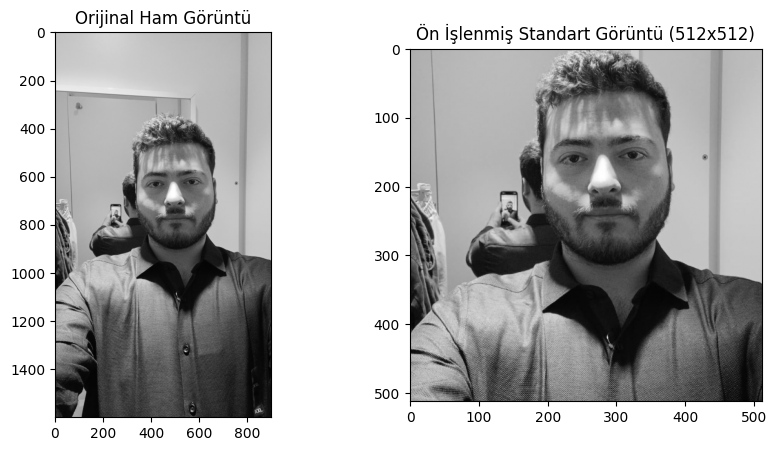

In [3]:
hedef_dosya = "goruntu1.jpeg"
tam_dosya_yolu = os.path.join(DATA_PATH, hedef_dosya)

img = cv2.imread(tam_dosya_yolu, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Görüntü yüklenemedi. Dosya yolunu kontrol edin: {tam_dosya_yolu}")

h, w = img.shape
kisa_kenar = min(h, w)
baslangic_y = (h - kisa_kenar) // 2
baslangic_x = (w - kisa_kenar) // 2
img_kare = img[baslangic_y : baslangic_y + kisa_kenar, baslangic_x : baslangic_x + kisa_kenar]

img_512 = cv2.resize(img_kare, (512, 512))
I = img_512 / 255.0

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Orijinal Ham Görüntü')
plt.subplot(1, 2, 2), plt.imshow(I, cmap='gray'), plt.title('Ön İşlenmiş Standart Görüntü (512x512)')
plt.show()

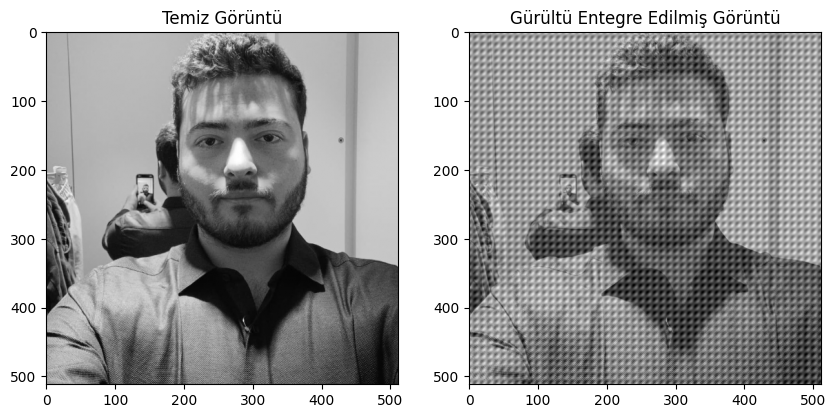

In [4]:
M, N = I.shape
x = np.arange(0, N)
y = np.arange(0, M)
X, Y = np.meshgrid(x, y)

freq = 0.1
genlik = 0.15

noise_diagonal = genlik * np.sin(2 * np.pi * freq * X + 2 * np.pi * freq * Y)
noise_vertical = genlik * np.sin(2 * np.pi * freq * X)
noise_horizontal = genlik * np.sin(2 * np.pi * freq * Y)

I_noisy = I + noise_diagonal + noise_vertical + noise_horizontal

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(I, cmap='gray'), plt.title('Temiz Görüntü')
plt.subplot(1, 2, 2), plt.imshow(I_noisy, cmap='gray'), plt.title('Gürültü Entegre Edilmiş Görüntü')
plt.show()

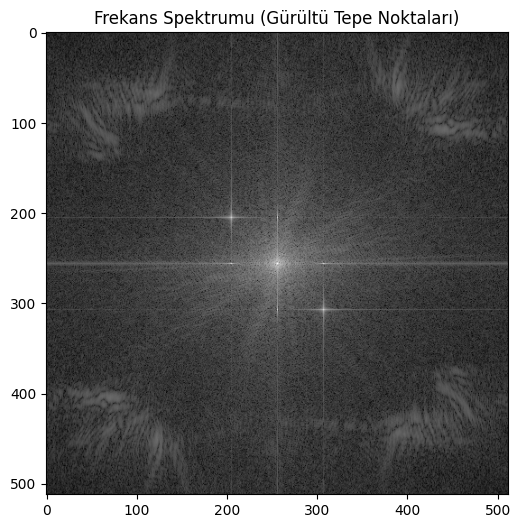

In [5]:
F = np.fft.fftshift(np.fft.fft2(I_noisy))

F_magnitude = np.log(1 + np.abs(F))

plt.figure(figsize=(6, 6))
plt.imshow(F_magnitude, cmap='gray')
plt.title('Frekans Spektrumu (Gürültü Tepe Noktaları)')
plt.show()

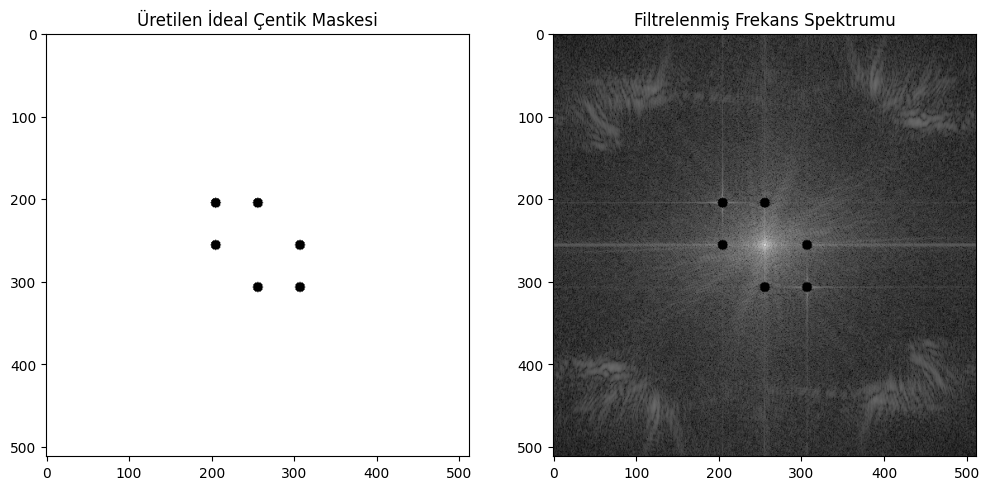

In [6]:
mask = np.ones((M, N))

merkez = 256
sapma = 51

notches = [
    [merkez + sapma, merkez + sapma],
    [merkez - sapma, merkez - sapma],
    [merkez, merkez + sapma],
    [merkez, merkez - sapma],
    [merkez + sapma, merkez],
    [merkez - sapma, merkez]
]

r = 6

for satir, sutun in notches:
    if 0 <= satir < M and 0 <= sutun < N:
        mask[((Y - satir)**2 + (X - sutun)**2) <= r**2] = 0

F_filtered = F * mask

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(mask, cmap='gray'), plt.title('Üretilen İdeal Çentik Maskesi')
plt.subplot(1, 2, 2), plt.imshow(np.log(1 + np.abs(F_filtered)), cmap='gray'), plt.title('Filtrelenmiş Frekans Spektrumu')
plt.show()